<a href="https://colab.research.google.com/github/woo-jungnam/TH-TTNT/blob/main/2001230540_NguyenThanhNam_B2_Bai3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [ ]:
# Placeholder for data loading
# You will replace this with your actual data loading code

# Dummy data for demonstration
# Let's assume images are 64x64 pixels and have 3 color channels (RGB)
IMG_HEIGHT = 64
IMG_WIDTH = 64
NUM_CHANNELS = 3
NUM_CLASSES = 2 # Cat or Dog

# Generate some random images and labels
# In a real scenario, these would come from your dataset
X_train = np.random.rand(1000, IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS).astype('float32')
y_train = np.random.randint(0, NUM_CLASSES, 1000)
X_val = np.random.rand(200, IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS).astype('float32')
y_val = np.random.randint(0, NUM_CLASSES, 200)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of X_train: (1000, 64, 64, 3)
Shape of y_train: (1000,)
Shape of X_val: (200, 64, 64, 3)
Shape of y_val: (200,)


In [ ]:
def build_cnn_model(input_shape, num_classes):
    model = keras.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Flatten the output for the Dense layers
        layers.Flatten(),

        # Dense (Fully Connected) Layers
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Dropout for regularization
        layers.Dense(num_classes, activation='softmax') # Output layer
    ])
    return model

# Build the model
input_shape = (IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS)
model = build_cnn_model(input_shape, NUM_CLASSES)

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,458 (2.61 MB)

 Trainable params: 683,458 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model (using dummy data)
# In a real scenario, you would use your actual training data (X_train, y_train)
# and validation data (X_val, y_val)
epochs = 10  # You might need more epochs for real data
batch_size = 32

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val)
)

print("\nModel training complete with dummy data.")

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step - accuracy: 0.5100 - loss: 0.6933 - val_accuracy: 0.5350 - val_loss: 0.6924
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 200ms/step - accuracy: 0.5110 - loss: 0.6925 - val_accuracy: 0.5350 - val_loss: 0.6917
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 206ms/step - accuracy: 0.4970 - loss: 0.6938 - val_accuracy: 0.5350 - val_loss: 0.6918
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step - accuracy: 0.5000 - loss: 0.6944 - val_accuracy: 0.5350 - val_loss: 0.6921
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 227ms/step - accuracy: 0.4980 - loss: 0.6934 - val_accuracy: 0.5350 - val_loss: 0.6921
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 222ms/step - accuracy: 0.5150 - loss: 0.6928 - val_accuracy: 0.5350 - val_loss: 0.6922
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step - accuracy: 0.5100 - loss: 0.6931 - val_accuracy: 0.5350 - val_loss: 0.6918
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step - accuracy: 0.5110 - loss: 0.6925 - val_accuracy

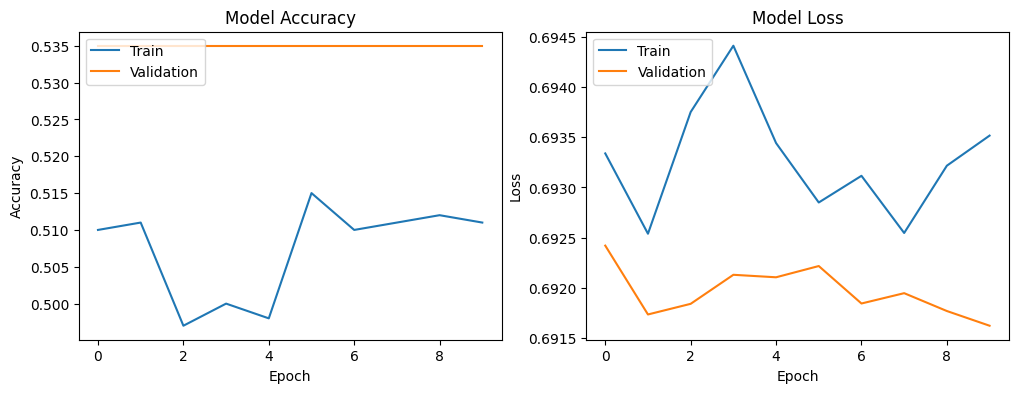

In [8]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()